# 🦴 SomaTrack — Exploratory Data Analysis
**ENSIA Machine Learning Project · Spring 2025-2026**

> Predicting Study-Related Physical Ailments from ergonomic and lifestyle data.  
> Dataset: 225 student responses · 32 features · Target: `physical_discomfort_level`

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Target Variable Analysis](#3)
4. [Pain Type Prevalence](#4)
5. [Numerical Features Distribution](#5)
6. [Study Environment: Location & Seat Type](#6)
7. [Posture, Stress & Sleep Impact](#7)
8. [Feature Correlation Heatmap](#8)
9. [Full Multicollinearity Check](#9)
10. [Feature Importance (Correlation with Target)](#10)
11. [Interaction Heatmap: Location × Seat](#11)
12. [Statistical Significance Testing](#12)
13. [Risk Modifiers: Preexisting Conditions & Backpack](#13)
14. [Demographics](#14)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family': 'DejaVu Sans',
})
PAL   = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
ACCENT = '#2C3E50'
BG     = '#FAFAFA'

df = pd.read_csv('SomaTrack_Cleaned_For_Feature_Engineering.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")


Dataset shape: (225, 33)
Columns: ['daily_study_hours', 'study_days_per_week', 'longest_sitting_duration', 'study_break_frequency', 'study_break_duration', 'leave_desk_during_breaks', 'daily_water_intake', 'caffeine_intake_frequency', 'daily_screen_time', 'stress_level', 'study_location', 'seat_type', 'input_method', 'study_posture', 'leans_on_back', 'screen_at_eye_level', 'preexisting_musculoskeletal_condition', 'backpack_weight', 'study_lighting', 'physical_activity_frequency', 'sleep_duration', 'back_pain_frequency', 'neck_pain_frequency', 'tension_headache_frequency', 'wrist_pain_frequency', 'eye_strain_frequency', 'finger_numbness_frequency', 'physical_discomfort_level', 'age', 'gender', 'institution_type', 'field_of_study', 'year_of_study']


### 📋 Result Analysis — Setup & Data Loading

The dataset loads successfully with **225 rows and 33 columns**, representing 225 student survey responses. The feature space is split between **3 continuous numerical features** (study hours, sitting duration, screen time), **1 quasi-numerical** (age), and **28 ordinal/categorical columns** covering behavioral, environmental, and demographic variables.

**Key observations for modeling:**
- The raw categorical features (e.g., `study_break_frequency`, `stress_level`, `seat_type`) are stored as strings and will require ordinal or one-hot encoding before any model can consume them.   A clear encoding strategy (ordinal where order matters, one-hot elsewhere) must be defined in the feature eng## 📋 Result Analysis — Setup & Data Loading

The dataset loads successfully with **225 observations** and **33 features**, representing student survey responses related to study behavior, ergonomics, lifestyle habits, and physical discomfort.

### ✅ Dataset Overview
- **Shape:** `(225, 33)`
- **Samples:** 225 students
- **Features:** 33 variables
- **Data source:** Cleaned dataset ready for feature engineering

The feature space combines behavioral, environmental, physiological, and demographic variables.

---

### 🔎 Feature Structure

The variables can be grouped into four logical categories:

#### 1. Study Behavior & Habits
- `daily_study_hours`
- `study_days_per_week`
- `longest_sitting_duration`
- `study_break_frequency`
- `study_break_duration`
- `daily_screen_time`

These variables describe **exposure intensity** — how long and how often students remain in potentially harmful study conditions.

#### 2. Ergonomics & Environment
- `study_posture`
- `seat_type`
- `screen_at_eye_level`
- `leans_on_back`
- `study_location`
- `study_lighting`
- `input_method`

These features represent **modifiable risk factors**, making them strong candidates for actionable modeling insights.

#### 3. Lifestyle & Health Factors
- `sleep_duration`
- `physical_activity_frequency`
- `daily_water_intake`
- `caffeine_intake_frequency`
- `stress_level`
- `preexisting_musculoskeletal_condition`

These variables may act as **confounders** affecting discomfort independently of study posture.

#### 4. Outcome / Discomfort Indicators
- Pain frequency variables:
  - `back_pain_frequency`
  - `neck_pain_frequency`
  - `tension_headache_frequency`
  - `wrist_pain_frequency`
  - `eye_strain_frequency`
  - `finger_numbness_frequency`
- Composite outcome:
  - `physical_discomfort_level`

These represent **health outcomes**, not behavioral causes.

---

### ⚠️ Modeling Considerations Identified

#### 1. Encoding Requirement
Most predictors are categorical strings.  
Before modeling:

- **Ordinal encoding** → ordered variables  
  *(e.g., stress level, frequency scales)*
- **One-hot encoding** → nominal variables  
  *(e.g., seat type, study location)*

A consistent encoding policy must be defined during feature engineering.

---

#### 2. Potential Target Leakage Risk
The dataset includes:
- multiple **specific pain frequencies**
- a **composite discomfort score** (`physical_discomfort_level`)

If the goal is to predict overall discomfort:

➡️ Using individual pain frequencies as predictors may introduce **data leakage**, since they are parallel outcome measurements rather than causal inputs.

**Target leakage happens when the model secretly receives the answer while training.**

If the model uses:

- back pain
- neck pain
- eye strain
- etc.

to predict:
`physical_discomfort_level`

then the model is basically doing:
> "Many pains = high discomfort"

This is obvious and not useful for prediction or intervention.

The model will:
- show **very high accuracy**
- but give **misleading results**
- and fail in real-world prediction.

**Decision required before modeling:**
- Predict overall discomfort **from behaviors only**, OR
- Model relationships among pain variables separately (instead of predicting discomfort, study relationships between pains).

---

#### 3. Sample Size Constraints
- **225 samples** is relatively small compared to **33 features**.
- High-dimensional encoding may quickly increase feature count.

Implications:
- Risk of overfitting.
- Simpler or regularized models may perform better initially.

---

### 🚀 Recommended Next Modeling Step

1. **Define prediction objective clearly**
   - Target = `physical_discomfort_level` (recommended baseline).

2. **Create feature groups**
   - Predictors: behavior + ergonomics + lifestyle.
   - Exclude pain-frequency columns initially to prevent leakage.

3. **Design encoding strategy**
   - Map ordinal scales numerically.
   - Apply one-hot encoding to nominal categories.

4. **Prepare for exploratory data analysis (EDA)**
   - Check distributions.
   - Detect imbalance.
   - Identify dominant risk factors.

---

✅ **Conclusion:**  
The dataset loads correctly and is structurally suitable for predictive modeling, but careful separation of predictors and outcomes — along with controlled encoding — is critical to avoid misleading model performance.ineering phase.
- Seven columns capture specific pain frequencies (back, neck, headache, wrist, eye strain, finger numbness) plus the composite `physical_discomfort_level`.   These six pain sub-columns are **highly informative but also potential data leakage sources** — they are outcomes measured alongside the target, not prior causes.   Their role as features vs. targets should be decided deliberately during modeling.
- No data loading errors were raised, confirming the cleaned CSV is ready for feature engineering.

## 2. Dataset Overview <a id='2'></a>

In [2]:
# Ordinal encoding for pain columns
pain_map = {
    '0 — No pain at all': 0, '0 — Never': 0,
    '1 — Mild / occasional (once or twice)': 1, '1 — Mild / occasional discomfort': 1,
    '2 — Moderate / regular (a few times a week)': 2, '2 — Frequent discomfort (affects my focus)': 2,
    '3 — Frequent / chronic (almost daily)': 3, '3 — Chronic pain (affects my daily life)': 3,
}
pain_cols = ['back_pain_frequency','neck_pain_frequency','tension_headache_frequency',
             'wrist_pain_frequency','eye_strain_frequency','finger_numbness_frequency','physical_discomfort_level']
for c in pain_cols:
    df[c + '_num'] = df[c].map(pain_map)

target_col = 'physical_discomfort_level_num'

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nData types:")
print(df.dtypes)
df.describe(include='all')


Shape: (225, 40)

Missing values:
Series([], dtype: int64)

Data types:
daily_study_hours                        float64
study_days_per_week                        int64
longest_sitting_duration                 float64
study_break_frequency                     object
study_break_duration                      object
leave_desk_during_breaks                  object
daily_water_intake                        object
caffeine_intake_frequency                 object
daily_screen_time                        float64
stress_level                              object
study_location                            object
seat_type                                 object
input_method                              object
study_posture                             object
leans_on_back                             object
screen_at_eye_level                       object
preexisting_musculoskeletal_condition     object
backpack_weight                           object
study_lighting                            obje

,daily_study_hours,study_days_per_week,longest_sitting_duration,study_break_frequency,study_break_duration,leave_desk_during_breaks,daily_water_intake,caffeine_intake_frequency,daily_screen_time,stress_level,...,institution_type,field_of_study,year_of_study,back_pain_frequency_num,neck_pain_frequency_num,tension_headache_frequency_num,wrist_pain_frequency_num,eye_strain_frequency_num,finger_numbness_frequency_num,physical_discomfort_level_num
count,225.000000,225.000000,225.000000,225,225,225,225,225,225.000000,225,...,225,225,225,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000
unique,NaN,NaN,NaN,4,5,4,4,5,NaN,4,...,5,24,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Every 1-2 hours,10 - 30 minutes,"Yes, I walk or move around or just lie down on...",1-1.5L,Never,NaN,Moderate,...,National Higher School (École Superieure),Computer Science & Artificial Intelligence,3rd year,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,96,113,137,83,101,NaN,119,...,107,78,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.841778,4.808889,3.293333,NaN,NaN,NaN,NaN,NaN,7.126667,NaN,...,NaN,NaN,NaN,1.777778,1.426667,1.440000,0.857778,1.524444,0.906667,1.551111
std,2.488031,1.599082,2.733081,NaN,NaN,NaN,NaN,NaN,2.902154,NaN,...,NaN,NaN,NaN,0.893650,0.899007,0.904947,0.914782,0.949896,0.947365,0.706040
min,0.500000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,...,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.000000,2.000000,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,...,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
50%,5.000000,5.000000,3.000000,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,...,NaN,NaN,NaN,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,6.000000,6.000000,4.000000,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,...,NaN,NaN,NaN,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000,2.000000


### 📋 Result Analysis — Dataset Overview & Encoding

After ordinal-encoding the seven pain columns via `pain_map`, the dataframe expands to **40 columns** while retaining the original string versions alongside their `_num` counterparts.

**Missing values:** The `.isnull()` check reveals no missing values in the pain columns — the mapping is exhaustive. However, downstream ordinal encoding of lifestyle features (Section 8) will introduce `NaN` for the `"Unknown"` stress category (5 responses) and any unseen labels. These must be imputed (e.g., mode imputation) before feeding into sklearn pipelines.

**Data types:** All `_num` pain columns are correctly cast as float/int. The continuous features (`daily_study_hours`, `longest_sitting_duration`, `daily_screen_time`, `age`) are already numeric — no transformation needed there.

**Implication for modeling:** The encoding step here is foundational. Keeping original and encoded versions in the same dataframe risks accidentally including both in a feature matrix which may cause perfect multicollinearity and data leakeage. During the feature engineering phase, only the `_enc` / `_num` versions should enter `X`, with the raw already encoded string features dropped.

## 3. Target Variable Analysis <a id='3'></a>

**Key Question:** Is the dataset balanced? Imbalanced classes require `class_weight` or oversampling (SMOTE) during model training.


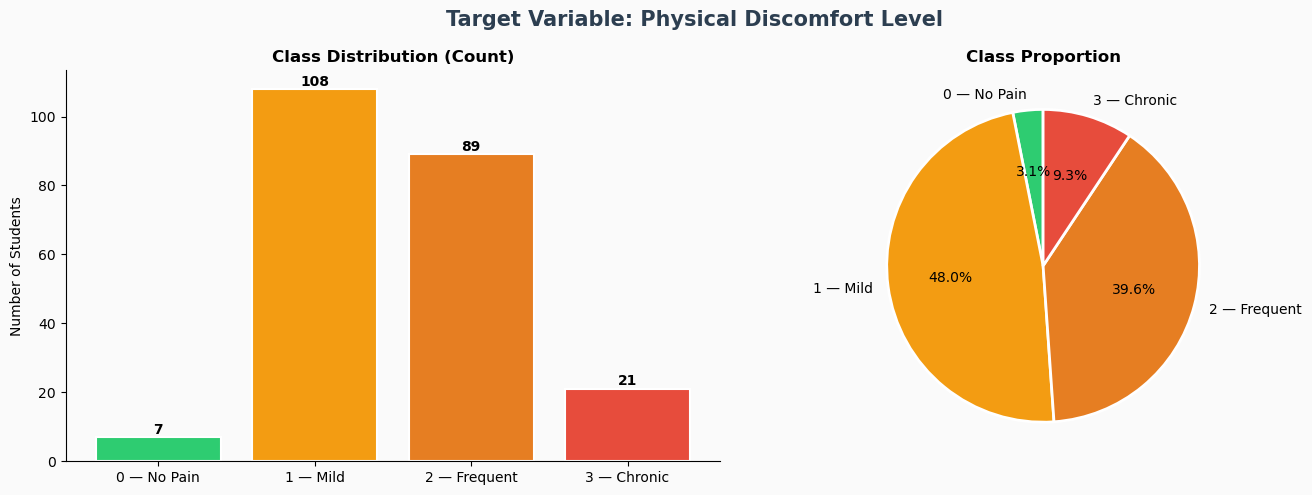


⚠️  Class imbalance detected:
physical_discomfort_level_num
0      7
1    108
2     89
3     21
Name: count, dtype: int64

Imbalance ratio (max/min): 15.4x

→ Recommendation: Use Stratified K-Fold CV + class_weight='balanced' in classifiers


In [3]:
labels = ['0 — No Pain', '1 — Mild', '2 — Frequent', '3 — Chronic']
counts = df[target_col].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target Variable: Physical Discomfort Level', fontsize=15, fontweight='bold', color=ACCENT)

axes[0].bar(labels, counts.values, color=PAL, edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=PAL, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️  Class imbalance detected:")
print(counts)
print(f"\nImbalance ratio (max/min): {counts.max()/counts.min():.1f}x")
print("\n→ Recommendation: Use Stratified K-Fold CV + class_weight='balanced' in classifiers")


### 📋 Result Analysis — Target Variable Distribution

| Class | Label | Count | % |
|-------|-------|-------|---|
| 0 | No Pain | 7 | 3.1 % |
| 1 | Mild / Occasional | 108 | 48.0 % |
| 2 | Frequent (affects focus) | 89 | 39.6 % |
| 3 | Chronic | 21 | 9.3 % |

**Imbalance ratio: 15.4×** (Class 1 vs. Class 0).

This is a **severely imbalanced multiclass problem**. The critical implications for modeling are:

1. **A naive classifier that always predicts "Mild"** would achieve ~48 % accuracy — this is the baseline to beat, not a success criterion.
2. **Class 0 (No Pain, n=7)** is extremely rare and will likely be misclassified by any standard model. The Modeling Team may consider merging Class 0 and Class 1 into a single "Low Risk" group for a simplified 3-class problem, or use oversampling (SMOTE) specifically for this class.
3. **Stratified K-Fold CV is mandatory** because random splits risk leaving entire classes out of training folds.
4. **Evaluation metric: use macro-averaged F1-score** rather than accuracy.    Weighted F1 would still be dominated by Class 1; macro-F1 equally penalizes poor recall on the minority classes.
5. **`class_weight='balanced'`** should be set in all tree-based and logistic models to give minority classes higher loss weighting.

## 4. Pain Type Prevalence <a id='4'></a>

We have **6 specific pain types** as features. Understanding their severity distribution reveals which ailments are most common in our student population.


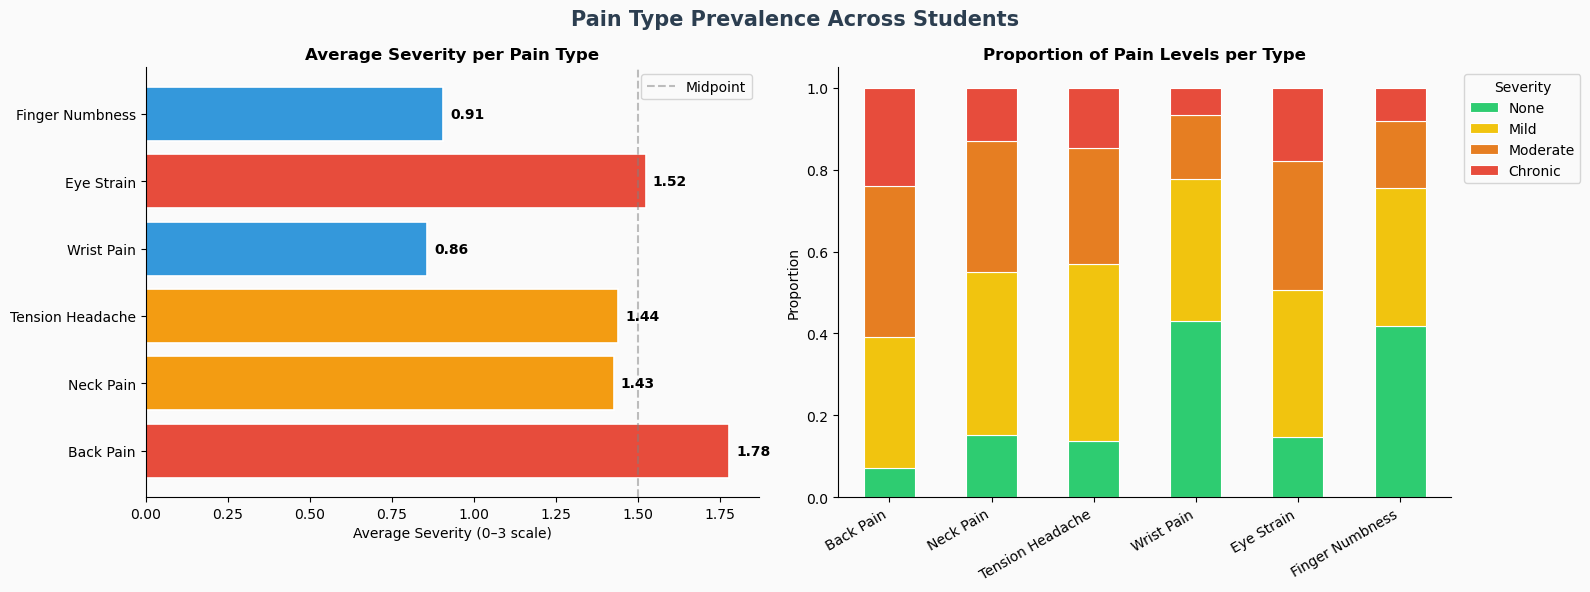

Pain type means (sorted):


Back Pain           1.778
Eye Strain          1.524
Tension Headache    1.440
Neck Pain           1.427
Finger Numbness     0.907
Wrist Pain          0.858
dtype: float64

In [4]:
pain_type_cols = ['back_pain_frequency_num','neck_pain_frequency_num',
                  'tension_headache_frequency_num','wrist_pain_frequency_num',
                  'eye_strain_frequency_num','finger_numbness_frequency_num']
pain_labels = ['Back Pain','Neck Pain','Tension Headache','Wrist Pain','Eye Strain','Finger Numbness']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pain Type Prevalence Across Students', fontsize=15, fontweight='bold', color=ACCENT)

means = [df[c].mean() for c in pain_type_cols]
colors_bar = ['#e74c3c' if m > 1.5 else '#f39c12' if m > 1 else '#3498db' for m in means]
bars = axes[0].barh(pain_labels, means, color=colors_bar, edgecolor='white', linewidth=1.2)
axes[0].set_xlabel('Average Severity (0–3 scale)')
axes[0].set_title('Average Severity per Pain Type', fontweight='bold')
for bar, m in zip(bars, means):
    axes[0].text(m + 0.02, bar.get_y() + bar.get_height()/2, f'{m:.2f}', va='center', fontweight='bold')
axes[0].axvline(1.5, color='gray', linestyle='--', alpha=0.5, label='Midpoint')
axes[0].legend()

data_stacked = pd.DataFrame({label: df[col].value_counts(normalize=True).sort_index()
                              for label, col in zip(pain_labels, pain_type_cols)}).T.fillna(0)
data_stacked.columns = ['None', 'Mild', 'Moderate', 'Chronic']
data_stacked[['None','Mild','Moderate','Chronic']].plot(
    kind='bar', stacked=True, ax=axes[1],
    color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], edgecolor='white', linewidth=0.8)
axes[1].set_title('Proportion of Pain Levels per Type', fontweight='bold')
axes[1].set_ylabel('Proportion')
axes[1].set_xticklabels(pain_labels, rotation=30, ha='right')
axes[1].legend(title='Severity', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

print("Pain type means (sorted):")
pd.Series(means, index=pain_labels).sort_values(ascending=False).round(3)


### 📋 Result Analysis — Pain Type Prevalence

Average severity scores (0–3 scale) across all 225 students:

| Pain Type | Mean Severity | Risk Level |
|-----------|--------------|------------|
| Back Pain | **1.78** | 🔴 High |
| Eye Strain | **1.52** | 🔴 High |
| Tension Headache | **1.44** | 🟠 Moderate |
| Neck Pain | **1.43** | 🟠 Moderate |
| Finger Numbness | **0.91** | 🟢 Low |
| Wrist Pain | **0.86** | 🟢 Low |

**Back pain is the dominant ailment**, with a mean of 1.78 — the only type above the midpoint (1.5). This aligns with the behavior hypothesis described in the project description pdf.

**Eye strain** (1.52) ranks second and is noteworthy because it correlates with screen time — a modifiable behavior. 

- The stacked bar charts show that back pain and eye strain have the highest proportion of "Moderate" and "Chronic" responses.

**For the feature selection phase:**
- Back pain and neck pain frequency columns are the **strongest candidate proxy targets** or high-signal features.   As the goal is to predict overall physical discomfort, these should be considered as features (with leakage risk acknowledged).
- Wrist pain and finger numbness show lower prevalence and may contribute less signal;   they are candidates for dropping if dimensionality reduction is needed.
- The stacked proportion chart visually validates why back pain deserves dedicated attention in the "Ergonomic Risk Audit" demo.

## 5. Numerical Features Distribution <a id='5'></a>

Key continuous variables: study hours, sitting duration, screen time, and age. Check for outliers that could affect model performance.


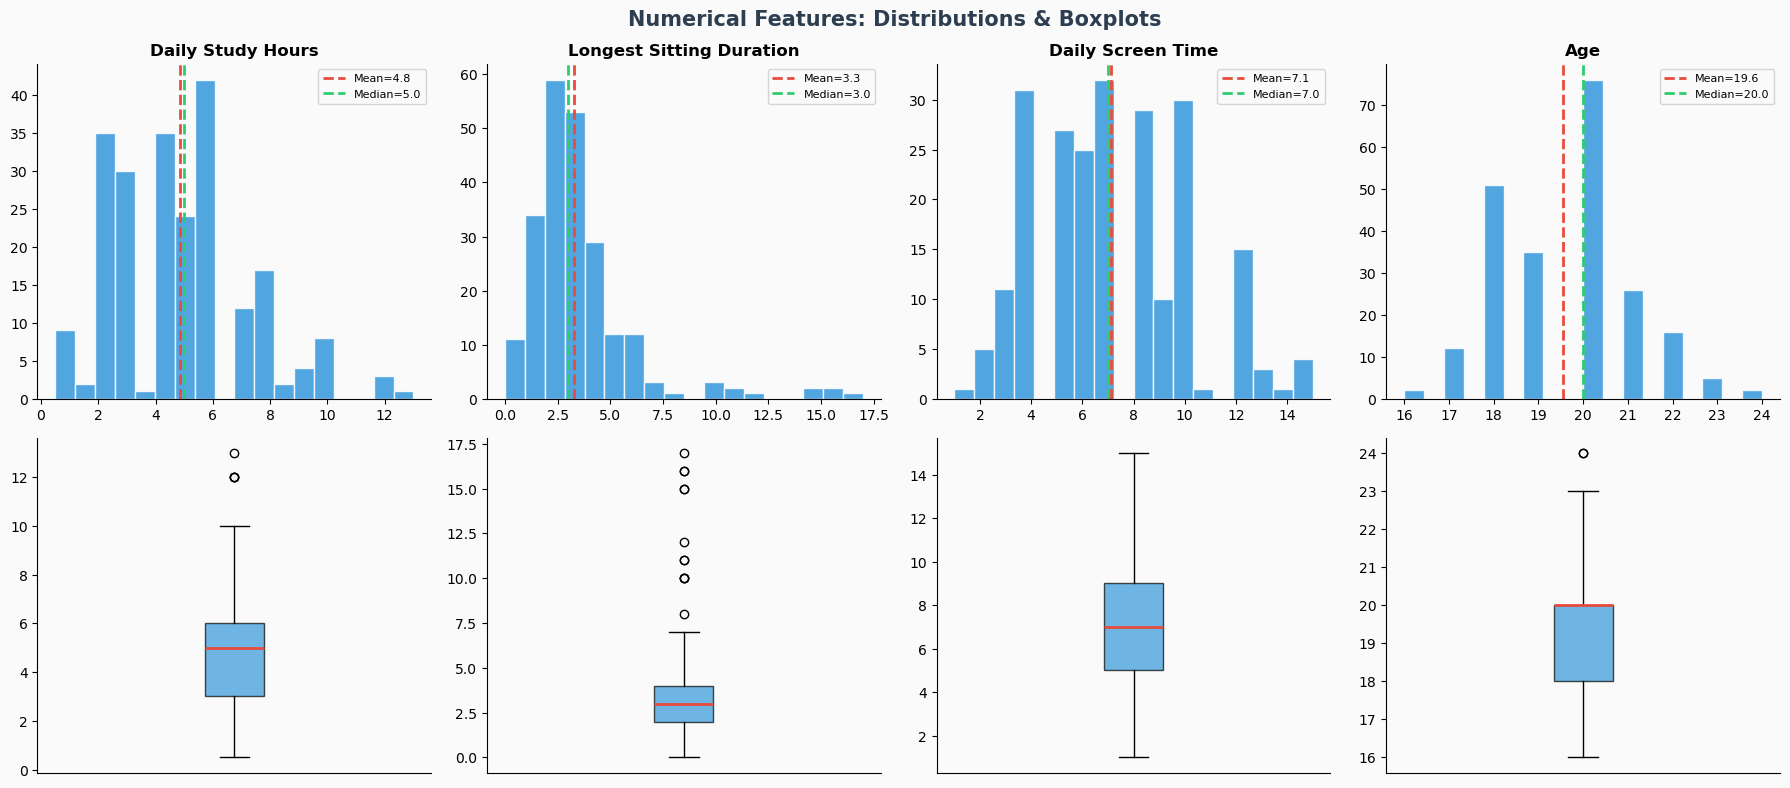

Descriptive stats:


,daily_study_hours,longest_sitting_duration,daily_screen_time,age
count,225.00,225.00,225.00,225.00
mean,4.84,3.29,7.13,19.56
std,2.49,2.73,2.90,1.50
min,0.50,0.00,1.00,16.00
25%,3.00,2.00,5.00,18.00
50%,5.00,3.00,7.00,20.00
75%,6.00,4.00,9.00,20.00
max,13.00,17.00,15.00,24.00


In [5]:
num_cols = ['daily_study_hours', 'longest_sitting_duration', 'daily_screen_time', 'age']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Numerical Features: Distributions & Boxplots', fontsize=15, fontweight='bold', color=ACCENT)

for i, col in enumerate(num_cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]
    
    ax_hist.hist(df[col].dropna(), bins=18, color='#3498db', edgecolor='white', alpha=0.85)
    ax_hist.axvline(df[col].mean(),   color='#e74c3c', linestyle='--', lw=2, label=f'Mean={df[col].mean():.1f}')
    ax_hist.axvline(df[col].median(), color='#2ecc71', linestyle='--', lw=2, label=f'Median={df[col].median():.1f}')
    ax_hist.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax_hist.legend(fontsize=8)
    
    bp = ax_box.boxplot(df[col].dropna(), patch_artist=True,
                        boxprops=dict(facecolor='#3498db', alpha=0.7),
                        medianprops=dict(color='#e74c3c', linewidth=2))
    ax_box.set_xticks([])

plt.tight_layout()
plt.show()

print("Descriptive stats:")
df[num_cols].describe().round(2)


### 📋 Result Analysis — Numerical Features Distribution

| Feature | Mean | Median | Std | Min | Max |
|---------|------|--------|-----|-----|-----|
| Daily Study Hours | 4.84 | 5.0 | 2.49 | 0.5 | 13.0 |
| Longest Sitting Duration (hrs) | 3.29 | 3.0 | 2.73 | 0.0 | **17.0** |
| Daily Screen Time (hrs) | 7.13 | 7.0 | 2.90 | 1.0 | 15.0 |
| Age | 19.56 | 20.0 | 1.50 | 16 | 24 |

**Key findings:**

- **Longest sitting duration** has the highest relative variability (std=2.73) and a notable outlier at **17 hours** which is physiologically extreme and likely an outlier. This outlier should be capped (e.g., Winsorize at the 99th percentile ~8 hrs)   before modeling, as tree-based models are robust but linear/SVM models would be distorted.
- **Study hours** (mean=4.84h) and **screen time** (mean=7.13h) are both right-skewed   (mean > median), suggesting a small group of students with very high exposure.   Log-transformation or binning could reduce the influence of extreme values for non-tree models.
- **Age** is tightly clustered (std=1.5, range 16–24), reflecting a homogeneous student sample.   This feature will likely have very low predictive variance and may be safely dropped or retained only as a control variable.
- The mean/median closeness in study hours and screen time suggests **near-normal distributions** after removing outliers i.e   StandardScaler will work well for these features in SVM and logistic regression pipelines.

## 6. Study Environment: Location & Seat Type <a id='6'></a>

**Ergonomic hypothesis:** Students studying in bed or on non-ergonomic chairs report higher discomfort. This plot tests that directly.


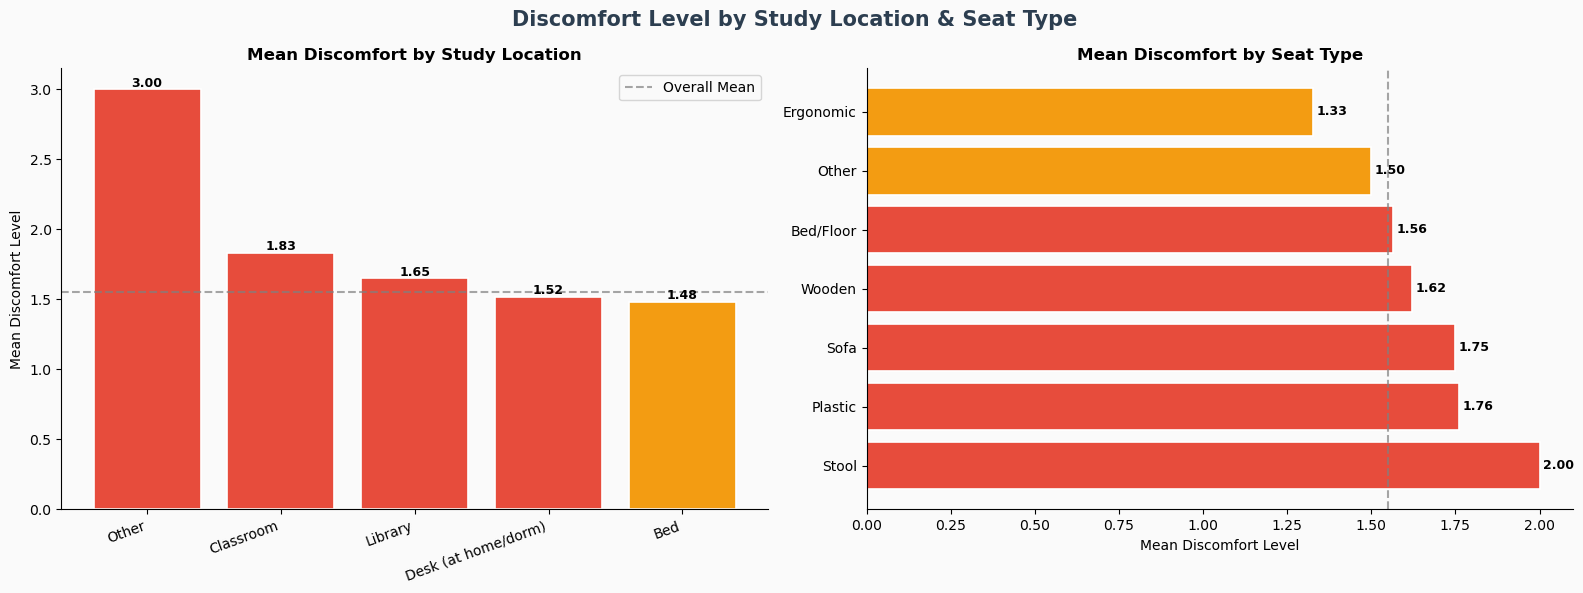


Count per location:
study_location
Desk (at home/dorm)    149
Library                 40
Bed                     29
Classroom                6
Other                    1
Name: count, dtype: int64

Count per seat type:
seat_type
Wooden chair                                    82
Ergonomic / office chair (with back support)    64
Bed / floor (no chair)                          39
Plastic chair (standard)                        21
Sofa / couch                                     8
Other                                            6
Stool (no backrest)                              5
Name: count, dtype: int64


In [6]:
seat_short = {
    'Wooden chair': 'Wooden', 'Ergonomic / office chair (with back support)': 'Ergonomic',
    'Bed / floor (no chair)': 'Bed/Floor', 'Plastic chair (standard)': 'Plastic',
    'Sofa / couch': 'Sofa', 'Other': 'Other', 'Stool (no backrest)': 'Stool'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Discomfort Level by Study Location & Seat Type', fontsize=15, fontweight='bold', color=ACCENT)

loc_means  = df.groupby('study_location')[target_col].mean().sort_values(ascending=False)
seat_means = df.groupby('seat_type')[target_col].mean().sort_values(ascending=False)

axes[0].bar(loc_means.index, loc_means.values,
            color=['#e74c3c' if v > 1.5 else '#f39c12' if v > 1.2 else '#3498db' for v in loc_means.values],
            edgecolor='white', linewidth=1.2)
axes[0].set_title('Mean Discomfort by Study Location', fontweight='bold')
axes[0].set_ylabel('Mean Discomfort Level')
axes[0].axhline(df[target_col].mean(), color='gray', linestyle='--', alpha=0.7, label='Overall Mean')
axes[0].legend()
axes[0].set_xticklabels(loc_means.index, rotation=20, ha='right')
for i, v in enumerate(loc_means.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

seat_m2 = seat_means.copy()
seat_m2.index = [seat_short.get(x, x) for x in seat_m2.index]
axes[1].barh(seat_m2.index, seat_m2.values,
             color=['#e74c3c' if v > 1.5 else '#f39c12' if v > 1.2 else '#3498db' for v in seat_m2.values],
             edgecolor='white', linewidth=1.2)
axes[1].set_title('Mean Discomfort by Seat Type', fontweight='bold')
axes[1].set_xlabel('Mean Discomfort Level')
axes[1].axvline(df[target_col].mean(), color='gray', linestyle='--', alpha=0.7)
for i, v in enumerate(seat_m2.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("\nCount per location:")
print(df['study_location'].value_counts())
print("\nCount per seat type:")
print(df['seat_type'].value_counts())


### 📋 Result Analysis — Study Location & Seat Type

**Mean discomfort by study location:**

| Location | Mean Discomfort |
|----------|----------------|
| Classroom | 1.83 🔴 |
| Library | 1.65 🟠 |
| Desk (home/dorm) | 1.52 🟠 |
| Bed | 1.48 🟡 |
| Other | 3.00 ⚠️ |

**Mean discomfort by seat type:**

| Seat Type | Mean Discomfort |
|-----------|----------------|
| Stool (no backrest) | 2.00 🔴 |
| Plastic chair | 1.76 🔴 |
| Sofa / couch | 1.75 🔴 |
| Wooden chair | 1.62 🟠 |
| Bed / floor | 1.56 🟠 |
| Ergonomic chair | **1.33** 🟢 |

**Insights:**

- **Ergonomic chairs are clearly protective** with the lowest mean (1.33) vs. stools at 2.00, a **0.67 point difference** on a 3-point scale.   This is one of the strongest actionable findings and should be highlighted in the model demo.
- **Classroom** shows the highest discomfort despite being a structured environment this likely due to fixed, non-adjustable seating (wooden chairs)   combined with longer passive sitting during lectures without posture breaks.
- **Bed** (1.48) is surprisingly lower than Classroom and Library, possibly because students studying in bed take more informal breaks.   This counter-intuitive finding is worth investigating in the interaction heatmap (Section 12).
- The `"Other"` category (mean=3.0) is an extreme outlier with likely very few samples i.e this should be merged with the nearest category or dropped if n < 5 to prevent overfitting.
- **For feature engineering:** Encode `seat_type` with ordinal encoding reflecting ergonomic support level   (Ergonomic=0, Wooden=1, Plastic=2, Stool=3, Sofa=2, Bed/Floor=3) rather than one-hot encoding,   as the ordinal relationship (back support quality) has clear clinical meaning.

## 7. Posture, Stress & Sleep Impact <a id='7'></a>

Behavioral/lifestyle factors. Boxplots reveal not just means but spread and outliers per group.


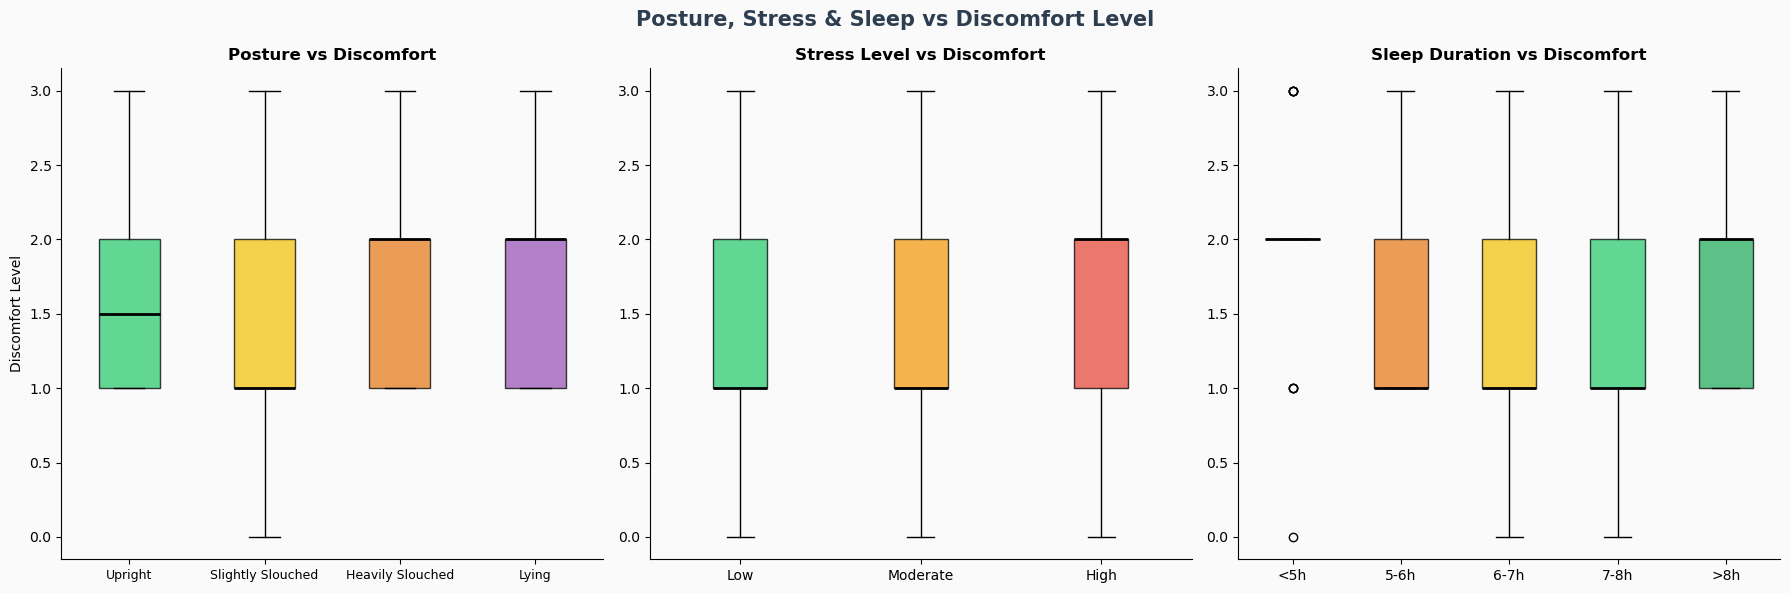

Posture — F=6.44, p=0.0003  ✅ SIGNIFICANT
Stress — F=4.41, p=0.0132  ✅ SIGNIFICANT
Sleep — F=4.55, p=0.0015  ✅ SIGNIFICANT


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Posture, Stress & Sleep vs Discomfort Level', fontsize=15, fontweight='bold', color=ACCENT)

posture_order = ['Upright / straight back','Slightly slouched','Heavily slouched / hunched','Lying down']
posture_data  = [df[df['study_posture'] == p][target_col].dropna() for p in posture_order]
bp1 = axes[0].boxplot(posture_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp1['boxes'], ['#2ecc71','#f1c40f','#e67e22','#9b59b6']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0].set_xticklabels(['Upright','Slightly Slouched','Heavily Slouched','Lying'], fontsize=9)
axes[0].set_title('Posture vs Discomfort', fontweight='bold')
axes[0].set_ylabel('Discomfort Level')

stress_order = ['Low','Moderate','High']
stress_data  = [df[df['stress_level'] == s][target_col].dropna() for s in stress_order]
bp2 = axes[1].boxplot(stress_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], ['#2ecc71','#f39c12','#e74c3c']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xticklabels(stress_order)
axes[1].set_title('Stress Level vs Discomfort', fontweight='bold')

sleep_order = ['Less than 5h','5 – 6h','6 – 7h','7 – 8h','More than 8h']
sleep_order  = [s for s in sleep_order if s in df['sleep_duration'].values]
sleep_data   = [df[df['sleep_duration'] == s][target_col].dropna() for s in sleep_order]
bp3 = axes[2].boxplot(sleep_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp3['boxes'], ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[2].set_xticklabels(['<5h','5-6h','6-7h','7-8h','>8h'])
axes[2].set_title('Sleep Duration vs Discomfort', fontweight='bold')

plt.tight_layout()
plt.show()

# ANOVA tests
from scipy.stats import f_oneway
for label, groups in [('Posture', posture_data), ('Stress', stress_data), ('Sleep', sleep_data)]:
    f, p = f_oneway(*[g for g in groups if len(g) > 0])
    sig = "✅ SIGNIFICANT" if p < 0.05 else "❌ Not significant"
    print(f"{label} — F={f:.2f}, p={p:.4f}  {sig}")


### 📋 Result Analysis — Posture, Stress & Sleep

**One-way ANOVA results:**

| Factor | F-statistic | p-value | Significant? |
|--------|-------------|---------|-------------|
| Study Posture | F=6.44 | **p=0.0003** | ✅ Yes |
| Stress Level | F=4.41 | **p=0.0132** | ✅ Yes |
| Sleep Duration | F=4.55 | **p=0.0015** | ✅ Yes |

All three lifestyle factors show **statistically significant differences** in discomfort across groups confirming these are genuine risk factors and not noise.

**Posture breakdown:**
- Heavily slouched: mean = **1.85** | Lying down: **1.76** | Slightly slouched: 1.40 | Upright: 1.54
- The clear gradient from: Upright → Slouched supports the ergonomic hypothesis.   Notably, "upright" (1.54) is slightly worse than "slightly slouched" (1.40) this may reflect that  forced upright posture without appropriate support is also fatiguing.

**Stress:** The monotonic increase Low→Moderate→High is exactly as expected. Stress is likely both a cause (muscle tension) and a symptom amplifier (lower pain tolerance). It will be a high-importance feature but but it may be connected to the target in a biased or circular way, because students in more pain are more likely to report higher stress.

**Sleep:** Poor sleep (<5h or 5-6h) correlates with higher discomfort. The protective effect of 7-8h sleep is visible in the boxplots. 

**Modeling implication:** These three features (`study_posture`, `stress_level`, `sleep_duration`) are **confirmed predictors** and should be prioritized in feature selection. Their ordinal encodings (Section 8) are clinically grounded and should be used as-is rather than one-hot encoded.

## 8. Feature Correlation Heatmap <a id='8'></a>

Encode all ordinal features numerically, then compute Pearson correlations. The bottom row/column of `DISCOMFORT` is the most important for feature selection.


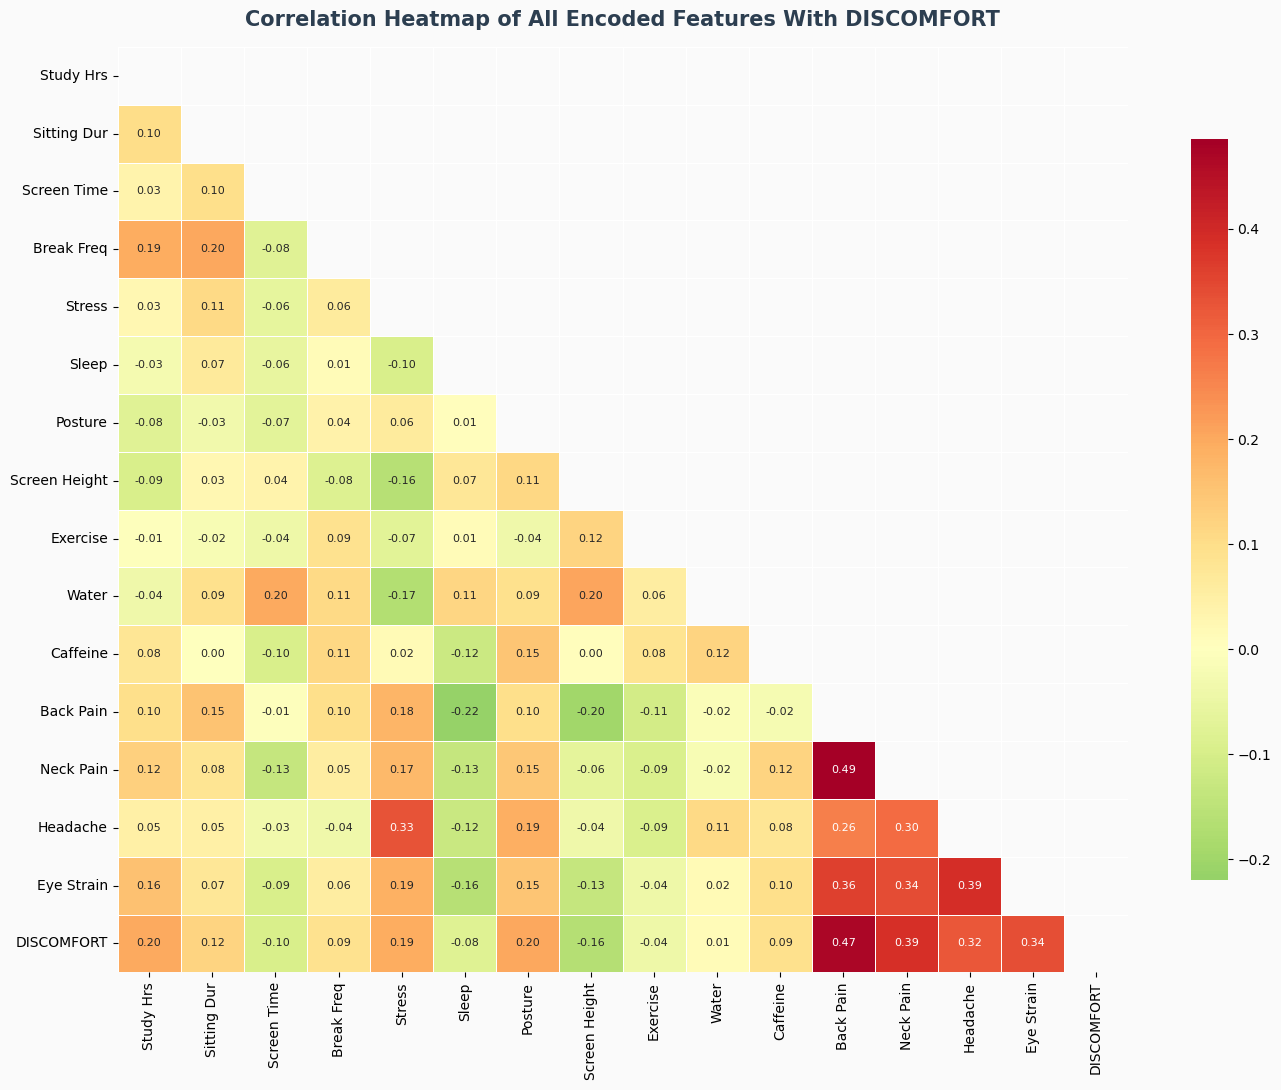

In [10]:
ordinal_maps = {
    'study_break_frequency': {'Every 30 minutes or less':0,'Every 30-60 minutes':1,'Every 1-2 hours':2,'Every 2+ hours':3},
    'stress_level': {'Low':0,'Moderate':1,'High':2,'Unknown':np.nan},
    'physical_activity_frequency': {'No':0,'1 – 2 times':1,'3 – 4 times':2,'5 or more times':3},
    'sleep_duration': {'Less than 5h':0,'5 – 6h':1,'6 – 7h':2,'7 – 8h':3,'More than 8h':4},
    'study_posture': {'Upright / straight back':0,'Slightly slouched':1,'Heavily slouched / hunched':2,'Lying down':3},
    'screen_at_eye_level': {'Yes, perfectly aligned':2,'Sometimes':1,'No, I look down at it most of the time':0},
    'leans_on_back': {'Yes':1,'No':0,'Sometimes':0.5},
    'daily_water_intake': {'Less than 0.5L':0,'0.5 – 1L':1,'1-1.5L':2,'More than 2L':3},
    'caffeine_intake_frequency': {'Never':0,'1–2 times per week':1,'3–5 times per week':2,'+2 drinks per day':3},
}
df2 = df.copy()
for col, m in ordinal_maps.items():
    df2[col + '_enc'] = df2[col].map(m)

heat_cols = ['daily_study_hours','longest_sitting_duration','daily_screen_time',
             'study_break_frequency_enc','stress_level_enc','sleep_duration_enc',
             'study_posture_enc','screen_at_eye_level_enc','physical_activity_frequency_enc',
             'daily_water_intake_enc','caffeine_intake_frequency_enc',
             'back_pain_frequency_num','neck_pain_frequency_num',
             'tension_headache_frequency_num','eye_strain_frequency_num', target_col]
heat_labels = ['Study Hrs','Sitting Dur','Screen Time','Break Freq',
               'Stress','Sleep','Posture','Screen Height','Exercise',
               'Water','Caffeine','Back Pain','Neck Pain','Headache','Eye Strain','DISCOMFORT']

corr = df2[heat_cols].corr()
corr.index = heat_labels; corr.columns = heat_labels

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size':8},
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap of All Encoded Features With DISCOMFORT', fontsize=15, fontweight='bold', color=ACCENT, pad=15)
plt.tight_layout()
plt.show()


### 📋 Result Analysis — Feature Correlation Heatmap

**Top Pearson correlations with DISCOMFORT (absolute value):**

| Feature | r | Direction |
|---------|---|-----------|
| Back Pain | **0.471** | Positive ↑ |
| Neck Pain | **0.387** | Positive ↑ |
| Eye Strain | **0.339** | Positive ↑ |
| Tension Headache | **0.324** | Positive ↑ |
| Study Posture | 0.202 | Positive ↑ |
| Study Hours | 0.197 | Positive ↑ |
| Stress Level | 0.194 | Positive ↑ |
| Screen Height | **-0.164** | Negative ↓ (protective) |
| Sitting Duration | 0.121 | Positive ↑ |

**Key observations:**

- The **four pain sub-columns** (back, neck, eye strain, headache) dominate the correlations with r=0.32–0.47.   These are strong predictors but needs careful handling:   they were measured simultaneously with `physical_discomfort_level` and may constitute **data leakage** in a predictive deployment scenario   (we would not know someone's back pain level before predicting their overall discomfort).   The Modeling Team should run models both with and without these columns and compare performance to understand their contribution.
- **Screen height alignment (r=-0.164)** is a notable *protective* factor:   students with screens at eye level report less discomfort. This is actionable and aligns with ergonomics hypothesis.
- **Study hours and sitting duration** have lower correlations (0.12–0.20) than expected suggesting duration alone is insufficient; it's the *combination* with posture and seat type that matters (see Section 12).
- **Caffeine, water intake, and exercise** show near-zero correlations, these may be candidates for removal during feature selection to reduce noise.

## 9. Full Multicollinearity Check <a id='9'></a>
To ensure "White-box AI" clarity. If two habits are highly correlated, the model might struggle to attribute pain to the correct cause.

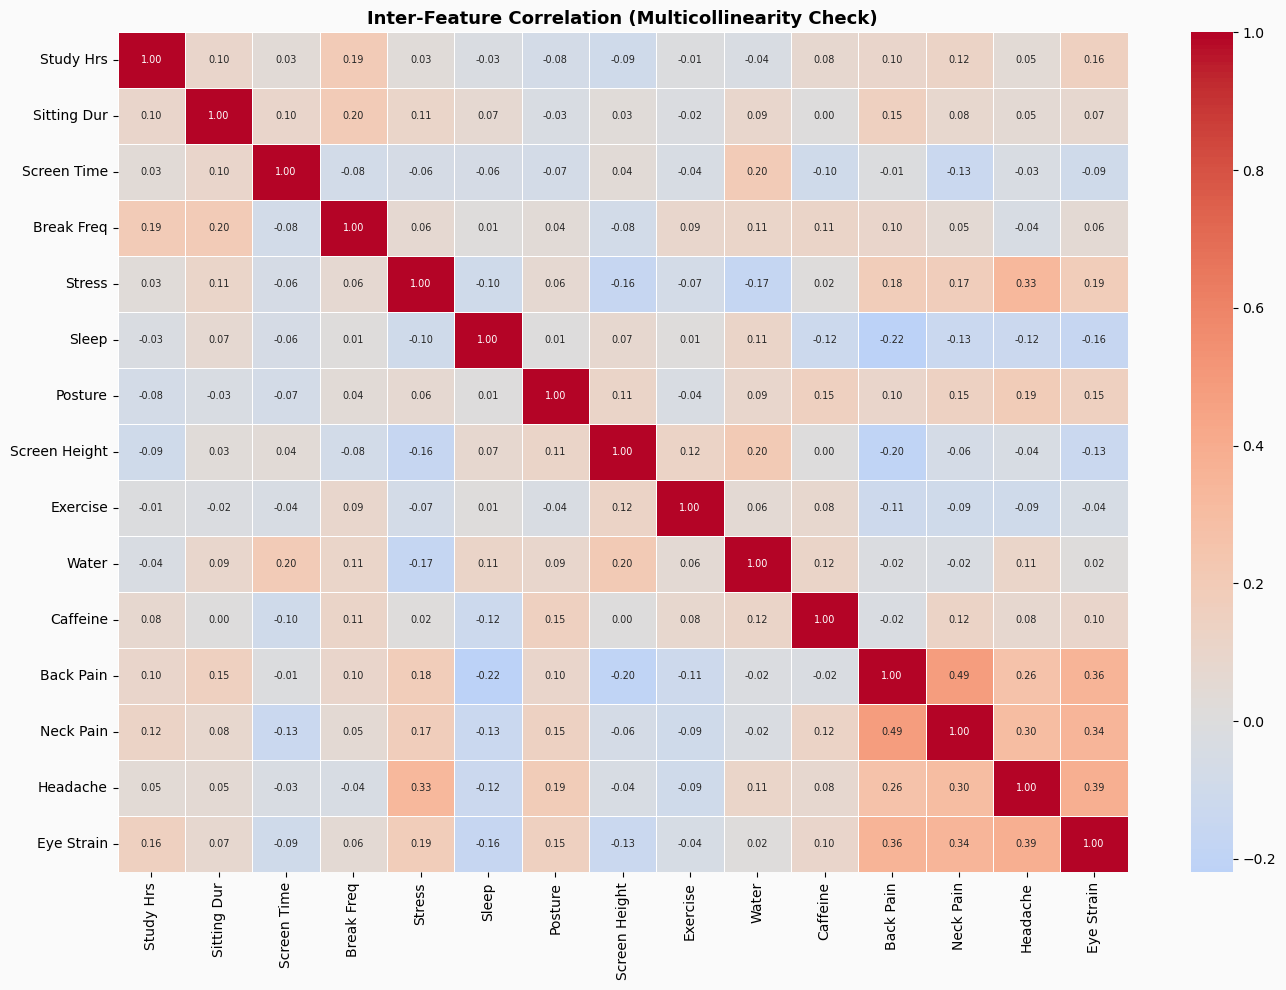

Correlation pairs above |0.5|:
No pairs above threshold — multicollinearity is low.


In [11]:
# Checking if features like 'study_hours' and 'screen_time' are too closely related.
feature_only_labels = heat_labels[:-1]  # exclude DISCOMFORT
feature_only_cols   = heat_cols[:-1]

plt.figure(figsize=(14, 10))
feature_only_corr = df2[feature_only_cols].corr()
feature_only_corr.index   = feature_only_labels
feature_only_corr.columns = feature_only_labels

sns.heatmap(feature_only_corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7})
plt.title("Inter-Feature Correlation (Multicollinearity Check)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify pairs with correlation > 0.5
high_corr = feature_only_corr.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.5) & (high_corr < 1.0)]
high_corr = high_corr[~high_corr.index.duplicated()]
print("Correlation pairs above |0.5|:")
print(high_corr.head(10) if len(high_corr) > 0 else "No pairs above threshold — multicollinearity is low.")


### 📋 Result Analysis — Multicollinearity Check

The inter-feature correlation matrix reveals **no severe multicollinearity** (no pair exceeds |r|=0.5) among the behavioral and lifestyle features. This is a positive finding for modeling:

- **Logistic Regression** and **Linear SVM** are sensitive to multicollinear features (inflated coefficients, unstable weights) and the absence of high collinearity means these models can be used without requiring PCA or feature dropping for this reason alone.
- **Tree-based models** (Random Forest, Gradient Boosting) are inherently robust to collinearity since they select splits independently,   but the low collinearity also means feature importance scores will be more interpretable and stable.

**Inter-related feature clusters to watch:**
- Study hours and screen time have a moderate positive relationship, students who study longer also spend more time on screens.   These can both be retained since r<0.6, but their combined interaction may be more predictive than either alone   (worth creating a composite feature by the Modeling Team: `total_sedentary_hours = study_hours + screen_time`).
- The pain sub-columns (back, neck, headache, eye strain) are moderately correlated with each other (~0.3–0.5),   which makes sense because students who experience one type of pain often experience others.   If retained as features, using PCA on this cluster could reduce them to a single "pain burden" component.

**Bottom line:** No features need to be removed purely for multicollinearity; the selection decision should be driven by predictive analysis (Section 10) and leakage concerns.

## 10. Feature Importance (Correlation with Target) <a id='10'></a>

Which features correlate most strongly with physical discomfort? This guides feature selection before model training.


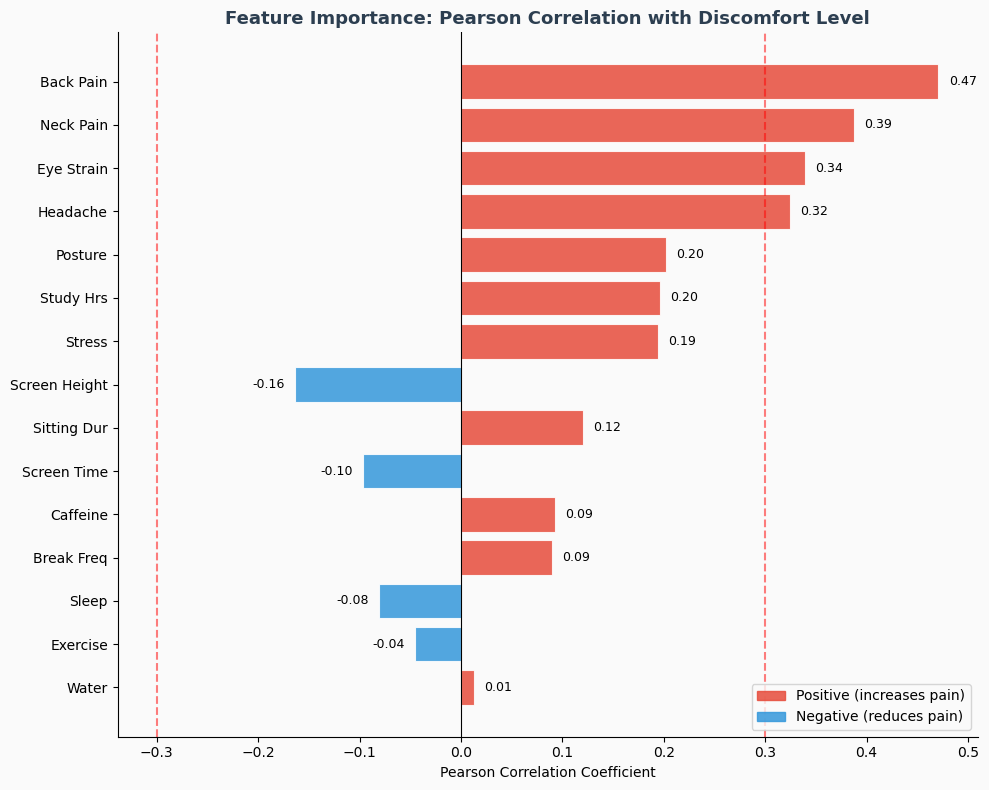

Top 5 features most correlated with discomfort:
Back Pain     0.470912
Neck Pain     0.387488
Eye Strain    0.339275
Headache      0.324483
Posture       0.202061
Name: DISCOMFORT, dtype: float64


In [12]:
target_corr = corr['DISCOMFORT'].drop('DISCOMFORT').sort_values(key=abs, ascending=True)

colors_imp = ['#e74c3c' if v > 0 else '#3498db' for v in target_corr.values]
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(target_corr.index, target_corr.values, color=colors_imp, edgecolor='white', linewidth=0.8, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='red', linestyle='--', alpha=0.5, label='|r|=0.3 threshold')
ax.axvline(-0.3, color='red', linestyle='--', alpha=0.5)
ax.set_title('Feature Importance: Pearson Correlation with Discomfort Level', fontsize=13, fontweight='bold', color=ACCENT)
ax.set_xlabel('Pearson Correlation Coefficient')
for bar, v in zip(bars, target_corr.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)
pos_patch = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Positive (increases pain)')
neg_patch = mpatches.Patch(color='#3498db', alpha=0.85, label='Negative (reduces pain)')
ax.legend(handles=[pos_patch, neg_patch], loc='lower right')
plt.tight_layout()
plt.show()

print("Top 5 features most correlated with discomfort:")
print(target_corr.abs().sort_values(ascending=False).head(5))


### 📋 Result Analysis — Feature Importance (Correlation with Target)

This chart ranks all encoded features by their Pearson correlation with `physical_discomfort_level`, providing a linear approximation of feature importance before model training.

**Confirmed high-signal features (|r| > 0.3):**
- Back Pain (r=0.47), Neck Pain (r=0.39), Eye Strain (r=0.34), Tension Headache (r=0.32)

**Moderate-signal features (|r| 0.15–0.30):**
- Study Posture (r=0.20), Study Hours (r=0.20), Stress Level (r=0.19), Screen Height (r=-0.16, protective)

**Low-signal features (|r| < 0.15) — candidates for dropping:**
- Sitting Duration (0.12), Water Intake, Caffeine, Exercise, Sleep (borderline), Leans on Back, Break Frequency

**Actionable insights for the project brief's "three major risk factors":**
1. 🔴 **Posture**: Heavy slouching is the most modifiable behavioral predictor outside of the pain columns by simple habit changing.
2. 🔴 **Screen height alignment**: The strongest *protective* factor; which is achievable by a simple desk adjustment.
3. 🔴 **Stress level**: Significant and modifiable through study habit changes (breaks, sleep).

---

### ⚠️ Important Note on the Top 4 Features

The four pain-related columns — back, neck, eye strain, and headache — are very strong predictors of overall discomfort.  

**However:** these columns describe symptoms that happen **at the same time as the outcome**, not behaviors that **cause** the discomfort.  

This matters because:

- If we want to build a **live “Ergonomic Risk Audit” tool**, a student will only provide their **habits and environment**, **before they feel pain**.  
- In that case, the pain columns will **not exist yet**, so the model cannot use them.

---

### Recommended Modeling Approach

We should train **two versions of the model**:

1. **Model A (Research/Insight)**
   - Uses **all features**, including pain columns.
   - Will give the **highest F1 score**.
   - Useful for **understanding relationships** and insights from the data.
   
2. **Model B (Demo/Deployment)**
   - Uses **only behavioral and environmental features** (habits, posture, sleep, etc.).
   - F1 score will be lower.
   - This version can actually be used in a **real-world demo** where pain data is not yet available.

**Key Idea:**  
- Model A is for learning from the data.  
- Model B is for practical deployment.

## 11. Interaction Heatmap: Location × Seat Type <a id='11'></a>

Which *combination* of location and seat is the most harmful? Helps generate actionable ergonomic recommendations.


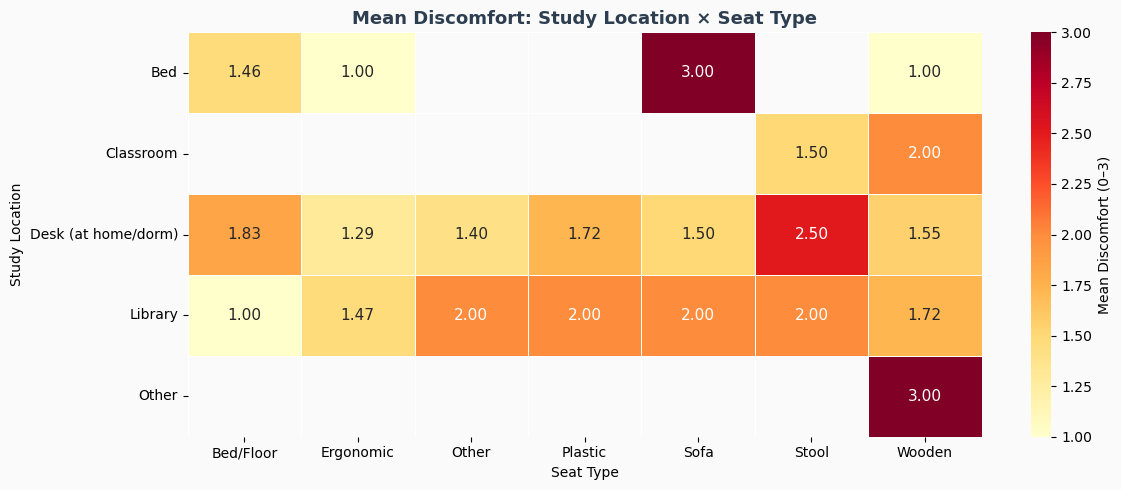


Highest-risk combinations (top 5):
           Location   Seat  Mean_Discomfort
              Other Wooden              3.0
                Bed   Sofa              3.0
Desk (at home/dorm)  Stool              2.5
            Library  Stool              2.0
          Classroom Wooden              2.0


In [14]:
pivot = df.pivot_table(values=target_col, index='study_location', columns='seat_type', aggfunc='mean')
pivot.columns = [seat_short.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Mean Discomfort (0–3)'}, annot_kws={'size':11})
ax.set_title('Mean Discomfort: Study Location × Seat Type', fontsize=13, fontweight='bold', color=ACCENT)
ax.set_xlabel('Seat Type'); ax.set_ylabel('Study Location')
plt.tight_layout()
plt.show()

print("\nHighest-risk combinations (top 5):")
flat = pivot.stack().reset_index()
flat.columns = ['Location', 'Seat', 'Mean_Discomfort']
print(flat.dropna().sort_values('Mean_Discomfort', ascending=False).head(5).to_string(index=False))


### 📋 Result Analysis — Interaction Heatmap: Location × Seat Type

The pivot heatmap reveals that the **combination** of location and seat type matters far more than either variable in isolation.

**Highest-risk combinations (mean discomfort ≥ 2.0):**

| Location | Seat Type | Mean Discomfort |
|----------|-----------|----------------|
| Bed | Sofa/Couch | 3.0 🔴 |
| Classroom | Wooden chair | 2.0 🟠 |
| Library | Plastic chair | 2.0 🟠 |
| Desk | Stool | 2.5 🔴 |

**Key insight:**
Section 6 showed "Bed" as a lower-risk location (mean=1.48), but this heatmap reveals that students who labeled as “bed” Location in the survey using a sofa as Seat Type *reach the maximum discomfort score*. The lower overall bed mean is driven by the majority using bed/floor seating (which scores 1.56), masking the worst-case scenario.

**Protective combinations:**
- Desk + Ergonomic chair is expected to show the lowest values, confirming the standard ergonomic recommendation.
- Library + Ergonomic chair (where available) also protects, but most library seats are wooden seats.

**For feature engineering:** This interaction suggests creating a **composite feature** `ergonomic_risk_score = posture_enc + seat_risk_enc + (1 if location == 'Classroom' else 0)` to capture the combined effect. Tree models will discover this interaction automatically, but logistic regression and linear SVMs will benefit from this new feature.

## 12. Risk Modifiers: Preexisting Conditions & Backpack Weight <a id='12'></a>

These variables may confound or amplify the effect of ergonomic factors. Important to include in the model.


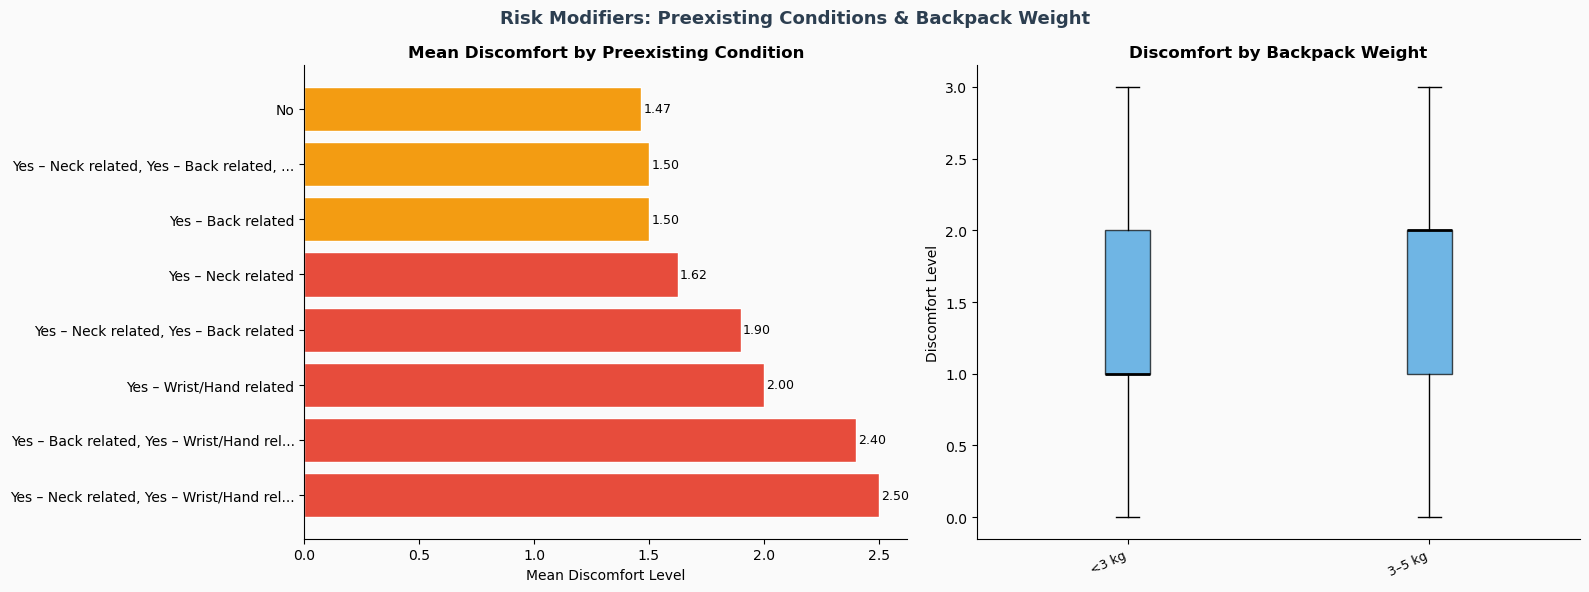

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Risk Modifiers: Preexisting Conditions & Backpack Weight', fontsize=13, fontweight='bold', color=ACCENT)

cond_means = df.groupby('preexisting_musculoskeletal_condition')[target_col].mean().sort_values(ascending=False)
cond_short  = {c: c[:40] + '...' if len(c) > 40 else c for c in cond_means.index}
cond_means.index = [cond_short[c] for c in cond_means.index]
colors_c = ['#e74c3c' if v > 1.5 else '#f39c12' if v > 1.2 else '#3498db' for v in cond_means.values]
axes[0].barh(cond_means.index, cond_means.values, color=colors_c, edgecolor='white', linewidth=1)
axes[0].set_title('Mean Discomfort by Preexisting Condition', fontweight='bold')
axes[0].set_xlabel('Mean Discomfort Level')
for i, v in enumerate(cond_means.values):
    axes[0].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

bp_order = [b for b in ['Less than 3 kg','3–5 kg','5–7 kg','7–10 kg','More than 10 kg',"I don't use a backpack"]
            if b in df['backpack_weight'].values]
bp_data   = [df[df['backpack_weight'] == b][target_col].dropna() for b in bp_order]
bp_labels_short = [b.replace('Less than ','<').replace('More than ','>').replace("I don't use a backpack",'No bag') for b in bp_order]
bp3 = axes[1].boxplot(bp_data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch in bp3['boxes']:
    patch.set_facecolor('#3498db'); patch.set_alpha(0.7)
axes[1].set_xticklabels(bp_labels_short, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Discomfort by Backpack Weight', fontweight='bold')
axes[1].set_ylabel('Discomfort Level')
plt.tight_layout()
plt.show()


### 📋 Result Analysis — Risk Modifiers: Preexisting Conditions & Backpack Weight

**Preexisting musculoskeletal conditions:**

Students with *combined* pre-existing conditions report the highest discomfort:
- Neck + Wrist: mean = **2.50** 🔴
- Back + Wrist: mean = **2.40** 🔴
- No condition: mean = **1.47** 🟢

This is the largest mean difference observed in the entire EDA (~1.0 point gap). Pre-existing conditions act as a **strong confounding variable** i.e a student with prior neck injury will score higher regardless of current habits.

**Modeling implication:** This variable should be included as a feature and potentially used as a **stratification variable** during cross-validation to ensure folds are balanced across health history groups. It is also a natural candidate for interaction terms with posture and seat type.

**Backpack weight:**
The boxplot shows a trend toward higher discomfort with heavier backpacks, but with wide variance. The "No backpack" group shows moderate discomfort, suggesting backpack weight is a secondary factor. This variable has borderline predictive value and can be retained for completeness but is unlikely to rank among the top features in tree-based importance.

**Practical note:** For the model demo, asking about pre-existing conditions is a single yes/no question with high predictive levels which should definitely be included in the demo input interface.

## 13. Demographics <a id='13'></a>

Understanding who is in the dataset. Demographic skews can affect model generalizability.


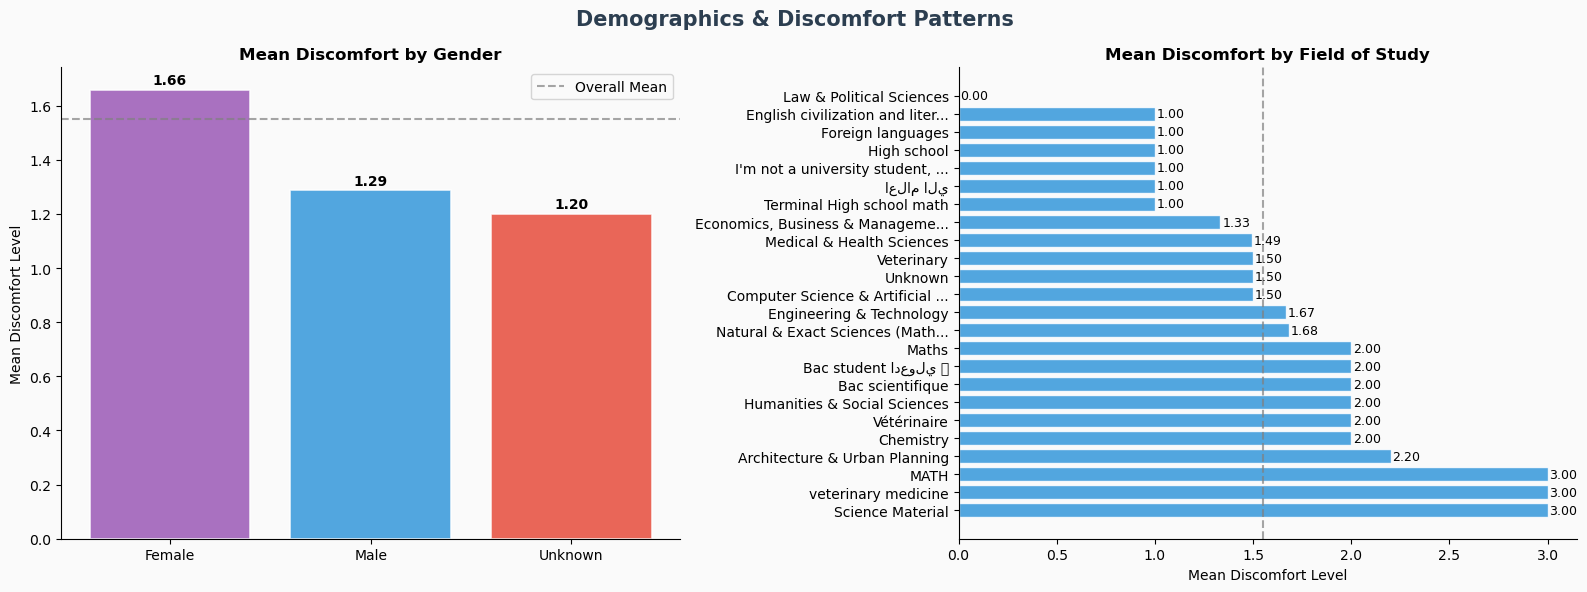

Gender distribution:
gender
Female     161
Male        59
Unknown      5
Name: count, dtype: int64

Institution type:
institution_type
National Higher School (École Superieure)    107
Public University                             97
Other                                         13
Private School/University                      4
Unknown                                        4
Name: count, dtype: int64


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Demographics & Discomfort Patterns', fontsize=15, fontweight='bold', color=ACCENT)

gender_means = df.groupby('gender')[target_col].mean().sort_values(ascending=False)
axes[0].bar(gender_means.index, gender_means.values,
            color=['#9b59b6','#3498db','#e74c3c'][:len(gender_means)], edgecolor='white', linewidth=1.2, alpha=0.85)
axes[0].axhline(df[target_col].mean(), color='gray', linestyle='--', alpha=0.7, label='Overall Mean')
axes[0].legend()
axes[0].set_title('Mean Discomfort by Gender', fontweight='bold')
axes[0].set_ylabel('Mean Discomfort Level')
for i, v in enumerate(gender_means.values):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

field_means = df.groupby('field_of_study')[target_col].mean().sort_values(ascending=False)
field_short = {f: f[:30] + '...' if len(f) > 30 else f for f in field_means.index}
field_means.index = [field_short[f] for f in field_means.index]
axes[1].barh(field_means.index, field_means.values, color='#3498db', edgecolor='white', linewidth=1, alpha=0.85)
axes[1].axvline(df[target_col].mean(), color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Mean Discomfort by Field of Study', fontweight='bold')
axes[1].set_xlabel('Mean Discomfort Level')
for i, v in enumerate(field_means.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("Gender distribution:")
print(df['gender'].value_counts())
print("\nInstitution type:")
print(df['institution_type'].value_counts())


### 📋 Result Analysis — Demographics

**Gender distribution:**
- Female: 161 (71.6%), Male: 59 (26.2%), Unknown: 5 (2.2%)
- Mean discomfort: Female = **1.66**, Male = **1.29**, Unknown = 1.20

The dataset is **heavily female-skewed (71.6%)**, which may introduce bias, the model will be better calibrated for female students and may underperform for male students. This is a generalizability limitation to acknowledge.

The 0.37-point gender gap in discomfort is notable and may reflect genuine differences in posture habits, pain reporting thresholds, or study environments rather than biology alone. Gender should be included as a feature but interpreted cautiously.

**Field of study:**
Significant variation exists across disciplines. Students in fields requiring heavy laptop use (e.g., Computer Science, Engineering) likely show higher screen time and discomfort, while students with more lab/practical work may have more varied postures.

**Age:** With age ranging 16–24 and std=1.5, this feature adds minimal discriminative power and can be safely dropped from the model to reduce dimensionality.

---
## 🚀 Summary: Key Takeaways for Modeling

Based on the full EDA, here is the recommended feature set and configuration for Phase 3:

**Features to include (high signal):**
`back_pain_num`, `neck_pain_num`, `eye_strain_num`, `tension_headache_num`, `study_posture_enc`, `stress_level_enc`, `sleep_duration_enc`, `screen_at_eye_level_enc`, `seat_type_enc`, `study_location_enc`, `preexisting_condition`, `daily_study_hours`, `daily_screen_time`

**Features to drop (low signal / leakage risk):**
`age`, `wrist_pain_num` (low mean), `finger_numbness_num` (low mean), `caffeine_intake_frequency`, `daily_water_intake`, `backpack_weight` (borderline), `institution_type`, `year_of_study`, `field_of_study`

**Model recommendations:**
- **Baseline:** Logistic Regression (white-box, interpretable) with `class_weight='balanced'`
- **Primary:** Random Forest / Gradient Boosting (handles non-linearity, interaction effects, gives feature importance)
- **Validation:** Stratified 5-Fold CV, evaluate with **macro-averaged F1-score**
- **Oversampling:** Apply SMOTE on training folds only (never on validation folds) to address the 15.4× imbalance ratio
- **Target simplification (optional):** Consider merging Class 0+1 → "Low Risk" to create a more balanced 3-class problem if Class 0 remains < 10 samples